In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

import kagglehub

# Data Acquisition


In [ ]:
# ----------------------------------------
# Data Acquisition
# ----------------------------------------

# Download the latest dataset version from Kaggle
path = kagglehub.dataset_download("kingabzpro/pokmon-legendary-data")

# print("Path to dataset files:", path)

dataset_path = "/root/.cache/kagglehub/datasets/kingabzpro/pokmon-legendary-data/versions/1"

csv_file_path = "/root/.cache/kagglehub/datasets/kingabzpro/pokmon-legendary-data/versions/1/pokedex.csv"

# Check if the CSV file exists
if not os.path.exists(csv_file_path):
    raise FileNotFoundError(f"The file {csv_file_path} does not exist.")
else:
    print(f"Found the file: {csv_file_path}")

# Load the CSV into a DataFrame with error handling
try:
    df = pd.read_csv(csv_file_path)
    print("DataFrame loaded successfully!")
except pd.errors.ParserError as e:
    raise ValueError(f"Error parsing the CSV file: {e}")
except UnicodeDecodeError as e:
    raise ValueError(f"Encoding error: {e}")
except Exception as e:
    raise RuntimeError(f"An unexpected error occurred: {e}")

# Display basic DataFrame information
print("\nFirst 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Information:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values in Each Column:")
print(df.isnull().sum())

Found the file: /root/.cache/kagglehub/datasets/kingabzpro/pokmon-legendary-data/versions/1/pokedex.csv
DataFrame loaded successfully!

First 5 rows of the DataFrame:
   pokedex_number        name  attack  defense  height_m  hp  percentage_male  \
0               1   Bulbasaur      49       49       0.7  45             88.1   
1               2     Ivysaur      62       63       1.0  60             88.1   
2               3    Venusaur     100      123       2.0  80             88.1   
3               4  Charmander      52       43       0.6  39             88.1   
4               5  Charmeleon      64       58       1.1  58             88.1   

   sp_attack  sp_defense  speed   type  weight_kg  generation  is_legendary  
0         65          65     45  grass        6.9           1             0  
1         80          80     60  grass       13.0           1             0  
2        122         120     80  grass      100.0           1             0  
3         60          50     65   

# Data Preparation

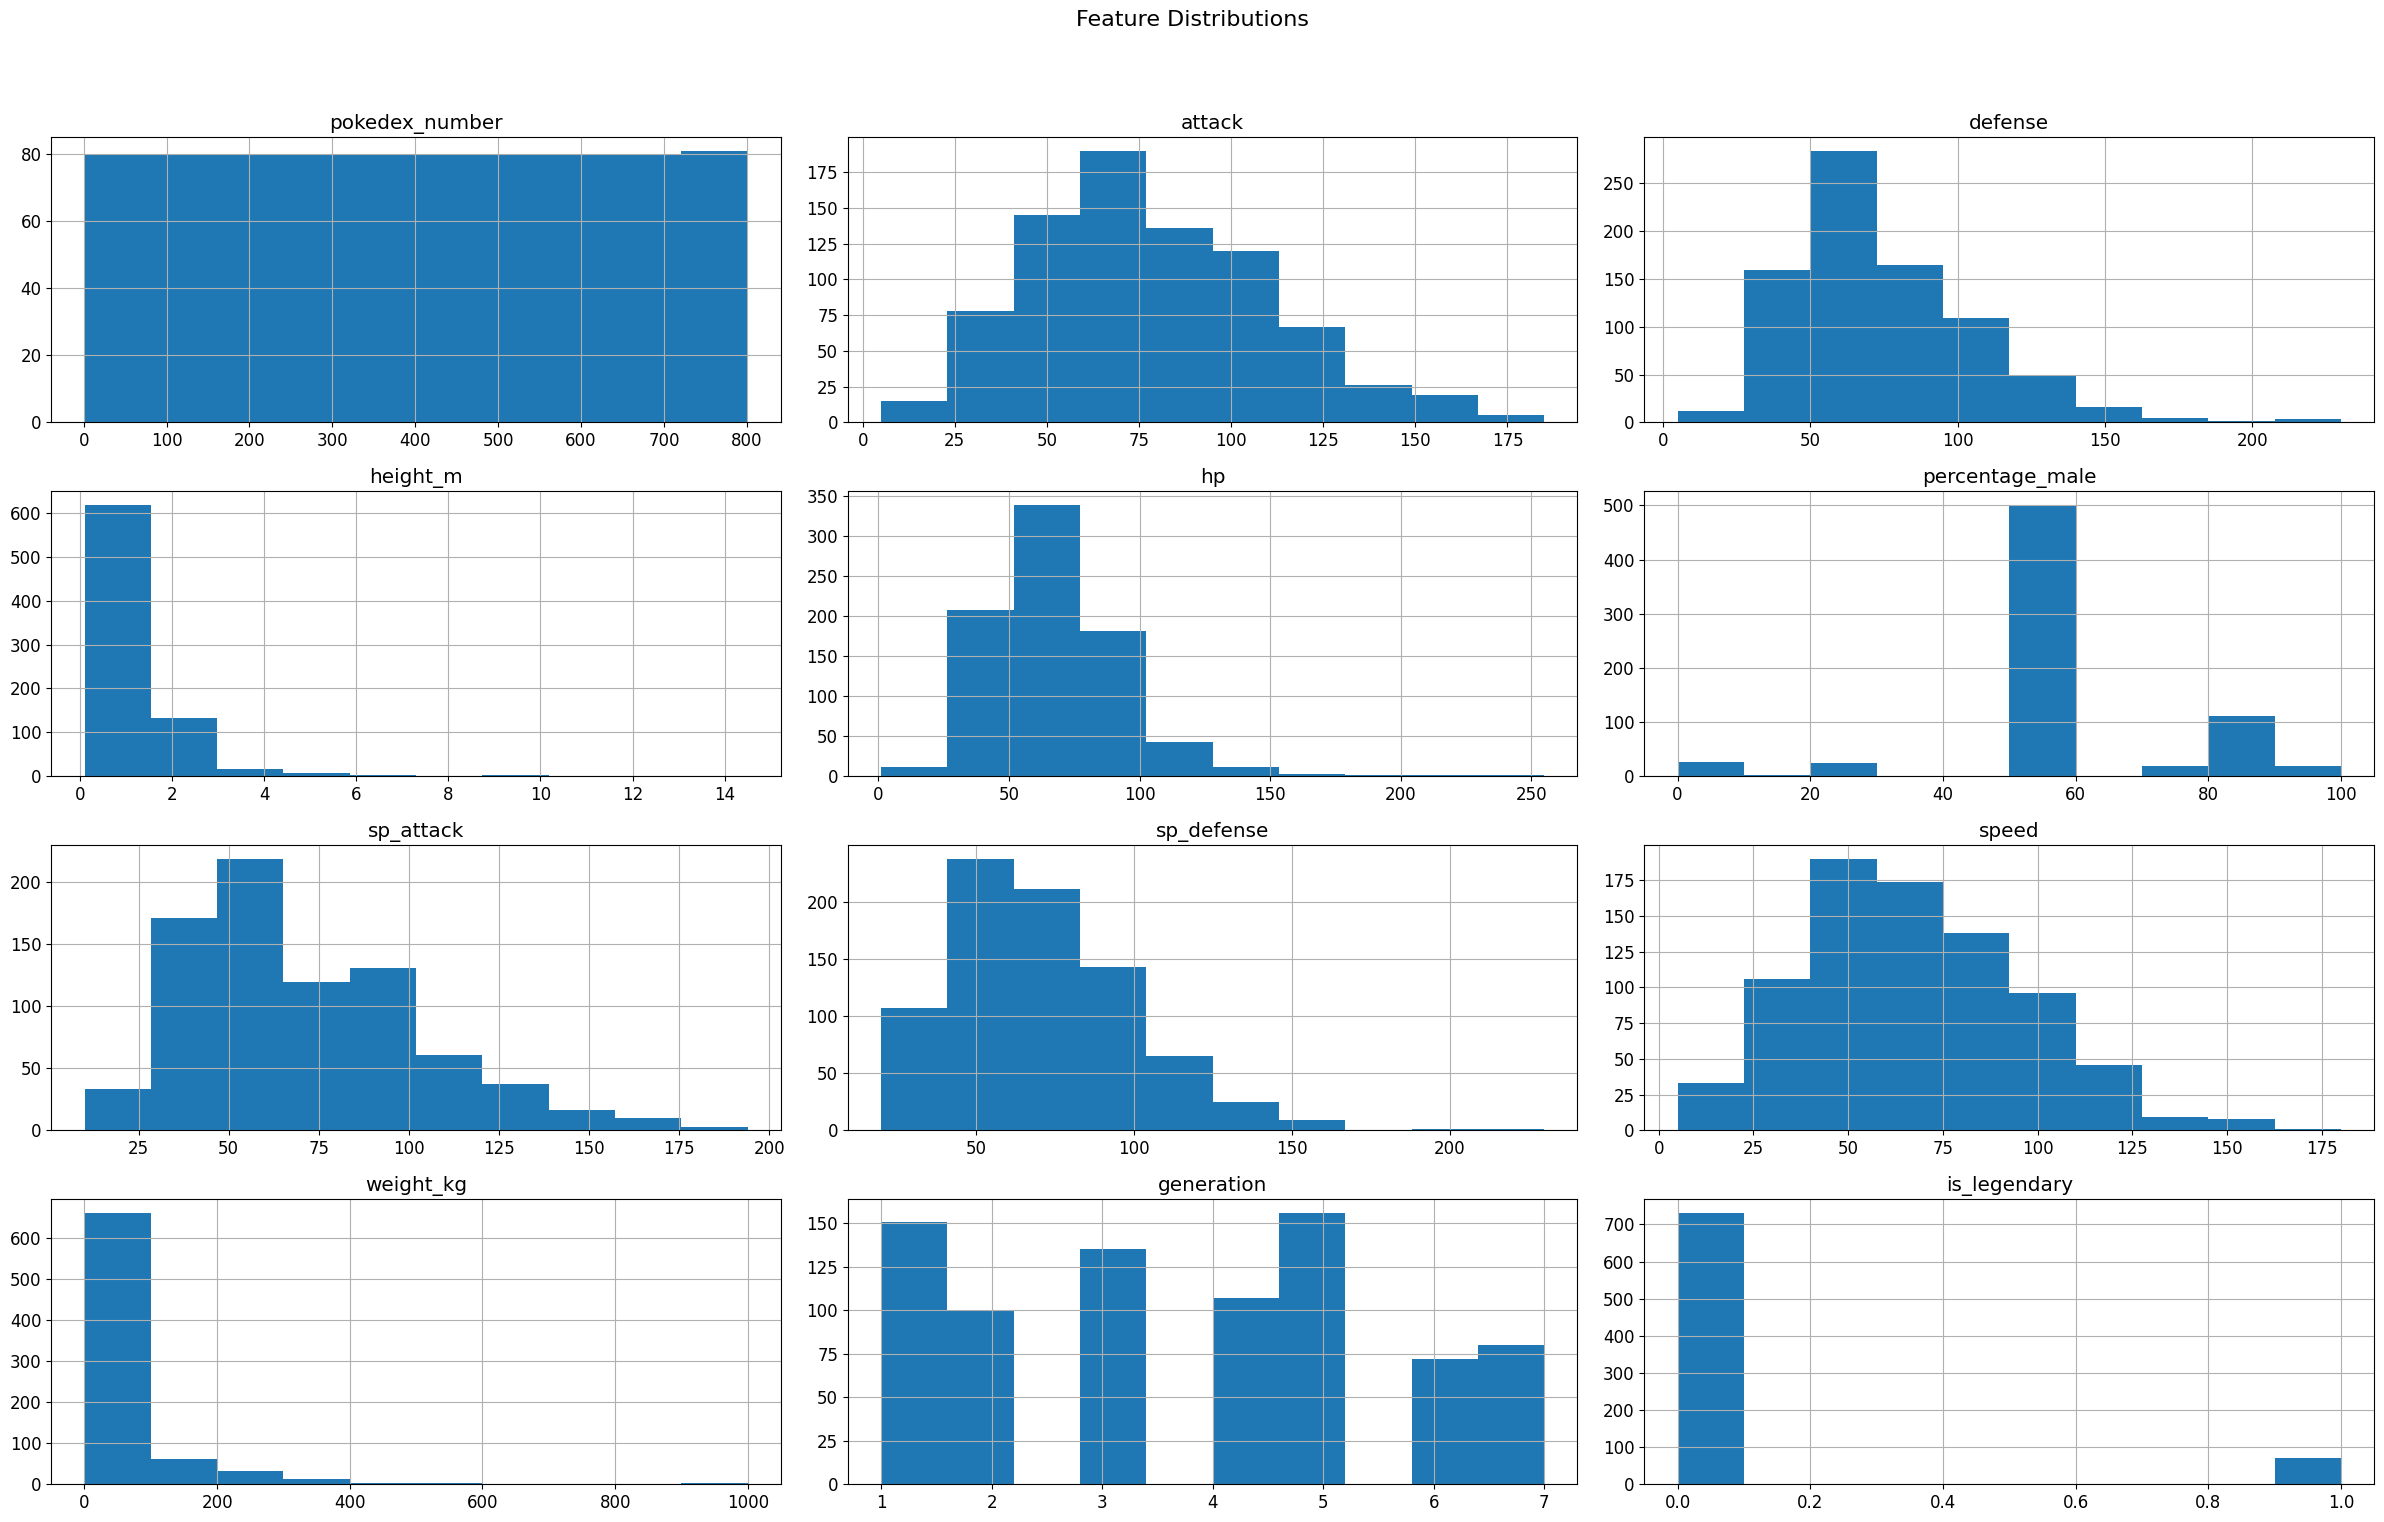

In [ ]:
# ----------------------------------------
# Data Preparation
# ----------------------------------------

# Visualize distributions of numerical features
plt.rcParams.update({'font.size': 12})
df.hist(figsize=(24, 16))
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



## Problem Context
Class Imbalance: In many datasets, especially classification problems, one class may be significantly underrepresented compared to others. In this case, non-legendary Pokémon are likely much more numerous than legendary ones. This imbalance can lead machine learning models to be biased toward the majority class (non-legendary Pokémon), reducing their effectiveness in predicting the minority class (legendary Pokémon).
##Solution: Using SMOTE to Balance the Dataset
SMOTE (Synthetic Minority Over-sampling Technique) is an advanced technique used to address class imbalance by generating synthetic samples for the minority class. Unlike simple over-sampling methods that duplicate existing minority samples, SMOTE creates new, synthetic instances that can help the model learn the decision boundaries more effectively.

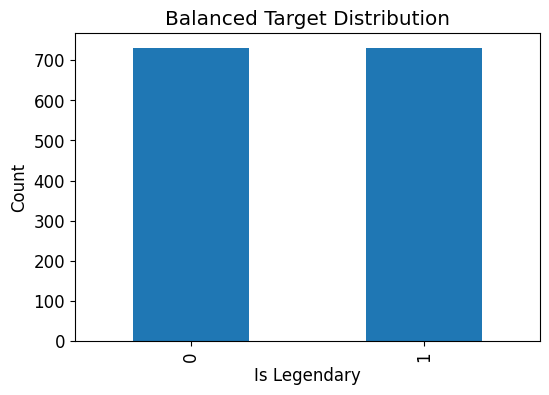

In [ ]:


# Define features and target
X = df.drop(['pokedex_number', 'name', 'is_legendary'], axis=1)
y = df["is_legendary"]

# Identify numerical and categorical features
numerical_features = [
    'attack', 'defense', 'height_m', 'hp', 'percentage_male',
    'sp_attack', 'sp_defense', 'speed', 'weight_kg', 'generation'
]
categorical_features = ['type']  # e.g. grass, ice, ground

# Define transformers for preprocessing
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Create a pipeline with preprocessing and SMOTE for balancing
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=0))
])

# Apply the pipeline to resample the data
X_resampled, y_resampled = pipeline.fit_resample(X, y)

# Visualize the balanced target distribution
y_resampled.value_counts().plot(kind='bar', figsize=(6, 4))
plt.title('Balanced Target Distribution')
plt.xlabel('Is Legendary')
plt.ylabel('Count')
plt.show()


# Train-Test Split

In [ ]:

# ----------------------------------------
# Train-Test Split
# ----------------------------------------

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=0,
    stratify=y_resampled
)

# Verify no missing values remain in the resampled features
X_resampled_df = pd.DataFrame(X_resampled)
missing_values = X_resampled_df.isnull().sum().sum()
print(f"Total missing values in resampled features: {missing_values}")

# ----------------------------------------
# Model Development
# ----------------------------------------

# Define classifier models to train
model_classes = {
    'DecisionTree': DecisionTreeClassifier,
    'RandomForest': RandomForestClassifier,
    'AdaBoost': AdaBoostClassifier,
    'GradientBoosting': GradientBoostingClassifier
}

# Initialize a dictionary to store trained classifiers
trained_classifiers = {}

# Train each classifier and store it
for model_name, clf_class in model_classes.items():
    print(f"Training {model_name}...")
    clf = clf_class(random_state=0)
    clf.fit(X_train, y_train)
    trained_classifiers[model_name] = clf

print("All classifiers have been trained.")


Total missing values in resampled features: 0
Training DecisionTree...
Training RandomForest...
Training AdaBoost...
Training GradientBoosting...
All classifiers have been trained.


# Model Evaluation

In [ ]:

# ----------------------------------------
# Model Evaluation
# ----------------------------------------

# Define metric functions
metrics = {
    'precision': precision_score,
    'recall': recall_score,
    'f1': f1_score
}

# Initialize a dictionary to store performance metrics
performance = {model: {} for model in model_classes.keys()}

# Evaluate each classifier on both training and testing sets
for model_name, clf in trained_classifiers.items():
    for dataset, X_set, y_set in [
        ('train', X_train, y_train),
        ('test', X_test, y_test)
    ]:
        y_pred = clf.predict(X_set)
        for metric_name, metric_func in metrics.items():
            if len(np.unique(y)) > 2 and metric_name != 'precision':
                score = metric_func(y_set, y_pred, average='macro')
            else:
                score = metric_func(y_set, y_pred)
            performance[model_name][f"{metric_name}_{dataset}"] = score

# Convert performance metrics to DataFrame
df_performance = pd.DataFrame(performance).T
df_performance = df_performance.round(3).reset_index().rename(columns={'index': 'Model'})
print("\nModel Performance Metrics:")
print(df_performance)

# Generate and display classification report for the last classifier on the test set
# (You may modify this to generate reports for specific models as needed)
last_model_name = list(trained_classifiers.keys())[-1]
last_clf = trained_classifiers[last_model_name]
y_pred_last = last_clf.predict(X_test)
report = classification_report(y_test, y_pred_last, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print(f"\nClassification Report for {last_model_name} on Test Set:")
print(df_report)



Model Performance Metrics:
              Model  precision_train  recall_train  f1_train  precision_test  \
0      DecisionTree            1.000         1.000     1.000           0.912   
1      RandomForest            1.000         1.000     1.000           0.966   
2          AdaBoost            0.978         0.978     0.978           0.964   
3  GradientBoosting            1.000         1.000     1.000           0.960   

   recall_test  f1_test  
0        0.925    0.918  
1        0.986    0.976  
2        0.918    0.940  
3        0.986    0.973  

Classification Report for GradientBoosting on Test Set:
              precision    recall  f1-score     support
0              0.986014  0.959184  0.972414  147.000000
1              0.960000  0.986301  0.972973  146.000000
accuracy       0.972696  0.972696  0.972696    0.972696
macro avg      0.973007  0.972743  0.972693  293.000000
weighted avg   0.973051  0.972696  0.972692  293.000000


# Visualization of Performance Metrics

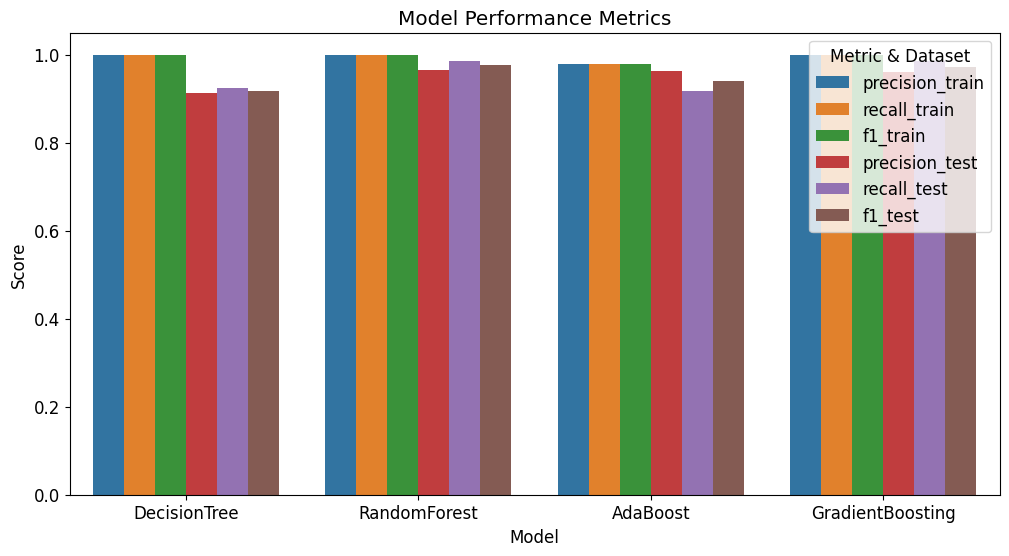

In [ ]:

# ----------------------------------------
# Visualization of Performance Metrics
# ----------------------------------------

# Melt the performance DataFrame for seaborn compatibility
df_melted = df_performance.melt(id_vars='Model', var_name='Metric_Dataset', value_name='Score')

# Plot the performance metrics
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric_Dataset', data=df_melted)
plt.title('Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(title='Metric & Dataset')
plt.show()


## **Understanding the Metrics**

Before interpreting the results, it's essential to understand what each metric signifies:

1. **Precision**:
   - **Definition:** The ratio of correctly predicted positive observations to the total predicted positives.
   - **Formula:**  
     \[
     \text{Precision} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Positives (FP)}}
     \]
   - **Interpretation:** High precision indicates that the model has a low false positive rate.

2. **Recall (Sensitivity or True Positive Rate)**:
   - **Definition:** The ratio of correctly predicted positive observations to all actual positives.
   - **Formula:**  
     \[
     \text{Recall} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}
     \]
   - **Interpretation:** High recall indicates that the model captures most of the positive instances.

3. **F1 Score**:
   - **Definition:** The harmonic mean of precision and recall.
   - **Formula:**  
     \[
     F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
     \]
   - **Interpretation:** The F1 score provides a balance between precision and recall, especially useful when you need to balance both concerns.

## **Performance Overview**

Here's a snapshot of your models' performance:

| Model                      | Precision (Train) | Recall (Train) | F1 Score (Train) | Precision (Test) | Recall (Test) | F1 Score (Test) |
|----------------------------|-------------------|----------------|-------------------|-------------------|---------------|------------------|
| DecisionTreeClassifier     | 1.000             | 1.000          | 1.000             | 0.912             | 0.925         | 0.918            |
| RandomForestClassifier     | 1.000             | 1.000          | 1.000             | 0.966             | 0.986         | 0.976            |
| AdaBoostClassifier         | 0.978             | 0.978          | 0.978             | 0.964             | 0.918         | 0.940            |
| GradientBoostingClassifier | 1.000             | 1.000          | 1.000             | 0.960             | 0.986         | 0.973            |

## **Interpreting the Results**

### **1. Training Performance**

- **All Models (DecisionTree, RandomForest, GradientBoosting):**
  - **Precision, Recall, and F1 Score are Perfect (1.000):**
    - **Implication:** These models have **perfectly** classified all training instances without any errors. This could be due to the models' inherent ability to fit complex patterns or potential **overfitting**, where the model learns the training data too well, including its noise and outliers.

- **AdaBoostClassifier:**
  - **Precision, Recall, and F1 Score are Slightly Below Perfect (0.978):**
    - **Implication:** AdaBoost has very high performance on the training set but not quite perfect, indicating a balance between fitting the data and maintaining some generalization.

### **2. Testing Performance**

- **DecisionTreeClassifier:**
  - **Precision:** 0.912
  - **Recall:** 0.925
  - **F1 Score:** 0.918
  - **Implication:** While still performing well, there's a noticeable drop from perfect training scores, suggesting some degree of overfitting. However, it maintains a strong balance between precision and recall.

- **RandomForestClassifier:**
  - **Precision:** 0.966
  - **Recall:** 0.986
  - **F1 Score:** 0.976
  - **Implication:** Exhibits excellent performance on the test set, with high precision and recall. This indicates that Random Forest generalizes well to unseen data, capturing most of the positive instances while maintaining a low false positive rate.

- **AdaBoostClassifier:**
  - **Precision:** 0.964
  - **Recall:** 0.918
  - **F1 Score:** 0.940
  - **Implication:** AdaBoost performs well but shows a slight imbalance between precision and recall on the test set. It maintains high precision but has a somewhat lower recall compared to other models, meaning it misses some positive instances.

- **GradientBoostingClassifier:**
  - **Precision:** 0.960
  - **Recall:** 0.986
  - **F1 Score:** 0.973
  - **Implication:** Similar to Random Forest, Gradient Boosting shows outstanding performance with high precision and recall, indicating strong generalization and effective handling of the classification task.

### **3. Comparing Training and Testing Performance**

- **Overfitting Indicators:**
  - **DecisionTreeClassifier and GradientBoostingClassifier:**
    - Perfect training scores coupled with slightly lower test scores suggest that these models may be overfitting, especially Decision Trees which are prone to this if not properly regularized.
  - **RandomForestClassifier:**
    - While it also has perfect training scores, the minimal drop in test performance suggests better generalization compared to a single Decision Tree.
  - **AdaBoostClassifier:**
    - Slightly lower training scores but still high test performance indicate a balanced model with minimal overfitting.

- **Generalization Ability:**
  - **RandomForestClassifier and GradientBoostingClassifier** demonstrate superior generalization, maintaining high performance on unseen data.
  - **DecisionTreeClassifier**, while still performing well, shows more signs of overfitting.
  - **AdaBoostClassifier** balances between training and testing performance but has a slight trade-off in recall.

### **4. Model Selection Recommendations**

Based on the provided metrics:

1. **RandomForestClassifier:**
   - **Pros:**
     - Highest precision and recall on the test set.
     - Excellent F1 score indicating balanced performance.
     - Robust against overfitting due to ensemble nature.
   - **Cons:**
     - Computationally more intensive compared to single trees.

2. **GradientBoostingClassifier:**
   - **Pros:**
     - Similar high performance to Random Forest.
     - Often performs well with careful tuning.
   - **Cons:**
     - More sensitive to hyperparameters.
     - Can be slower to train.

3. **DecisionTreeClassifier:**
   - **Pros:**
     - Simplicity and interpretability.
     - Fast to train and predict.
   - **Cons:**
     - Prone to overfitting.
     - Lower test performance compared to ensemble methods.

4. **AdaBoostClassifier:**
   - **Pros:**
     - Good balance between precision and recall.
     - Can perform well with appropriate base estimators.
   - **Cons:**
     - Slightly lower recall on the test set.
     - May require careful tuning to optimize performance.

**Recommendation:**  
**RandomForestClassifier** emerges as the top performer, offering the best balance of precision, recall, and F1 score on the test set. Its ensemble approach helps in mitigating overfitting, making it a reliable choice for your classification task.

## **Potential Reasons for Observed Performance**

1. **Ensemble Methods (Random Forest & Gradient Boosting):**
   - **Strengths:**
     - Combine multiple decision trees to improve generalization.
     - Reduce variance (Random Forest) or bias (Gradient Boosting).
     - Handle feature interactions effectively.
   - **Impact on Performance:**
     - Higher robustness and accuracy on unseen data compared to single classifiers.

2. **DecisionTreeClassifier:**
   - **Strengths:**
     - Simple and interpretable.
     - Can capture non-linear relationships.
   - **Weaknesses:**
     - High variance; prone to overfitting, especially with deep trees.
     - May not generalize well to unseen data without proper pruning or constraints.

3. **AdaBoostClassifier:**
   - **Strengths:**
     - Focuses on misclassified instances by previous classifiers.
     - Can convert weak learners into strong learners.
   - **Weaknesses:**
     - Sensitive to noisy data and outliers.
     - May struggle with classes that are not easily separable.

## **Additional Insights and Recommendations**

1. **Model Complexity:**
   - **Decision Trees** are more susceptible to overfitting, especially if they are allowed to grow without constraints. Consider limiting their depth or using pruning techniques to enhance generalization.

2. **Hyperparameter Tuning:**
   - **Random Forest and Gradient Boosting** can further improve performance with optimal hyperparameters. Techniques like **Grid Search** or **Randomized Search** with cross-validation can help identify the best settings.

3. **Cross-Validation:**
   - Implement **k-fold cross-validation** to ensure that the performance metrics are consistent across different subsets of the data, providing a more robust evaluation.

4. **Feature Importance and Selection:**
   - Analyze **feature importances** provided by ensemble models to understand which features contribute most to the predictions. This can guide feature engineering and selection for improved model performance.

5. **Handling Class Imbalance:**
   - Since you've employed **SMOTE** to balance classes, ensure that it's effectively enhancing model performance. Monitor for any residual imbalance or synthetic sample artifacts that might influence predictions.

6. **Evaluation Metrics Context:**
   - Depending on your application's priorities, you might prioritize **precision** over **recall** or vice versa. For instance:
     - **Precision-Focused:** Minimizing false positives (e.g., spam detection).
     - **Recall-Focused:** Minimizing false negatives (e.g., disease screening).

7. **Model Interpretability:**
   - While ensemble methods offer high performance, they can be less interpretable compared to single decision trees. If interpretability is crucial, consider techniques like **feature importance**, **SHAP values**, or using simpler models when appropriate.

8. **Scalability and Computational Resources:**
   - **Random Forests** and **Gradient Boosting** can be computationally intensive, especially with large datasets or numerous trees. Ensure that computational resources are sufficient, or consider model simplifications if necessary.

## **Conclusion**

Your classifiers demonstrate strong performance, especially the ensemble methods (**RandomForestClassifier** and **GradientBoostingClassifier**), which exhibit high precision, recall, and F1 scores on both training and testing datasets. While the **DecisionTreeClassifier** shows perfect training metrics, its slightly lower test performance indicates a need for tuning to prevent potential overfitting. The **AdaBoostClassifier** also performs admirably, balancing precision and recall effectively.

By focusing on ensemble methods and considering further hyperparameter optimization, you can enhance your model's robustness and predictive capabilities. Additionally, integrating visualization and deeper analysis of feature importances will provide more insights into your models' behaviors and areas for improvement.